In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

Torch version: 2.4.1.post300
CUDA available: False
CUDA device count: 0
CUDA device name: No CUDA device found
Using device: cpu
Torch Version: 2.4.1.post300
CUDA Version: 12.0
Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'BetaDirichletFactor.utils' from '/gpfs/commons/home/kisaev/Leaflet-private/src/BetaDirichletFactor/utils.py'>

In [2]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs/022025/anndatas/iPSC_human_Anndata_ATSE_counts_with_waypoints_20250214_171021.h5ad"
ATSE_file="/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs/022025/output/TMS_atse_file_unanno_also_2025-02-11_21-50-55.txt.gz"

# Define directory where output files should be saved 
output_dir="/gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs/022025/output/" 
# Make a directory for the output files inside the output directory with today's date, inside of that make a directory for the run with the current time
date=datetime.datetime.now().strftime("%Y-%m-%d")
time=datetime.datetime.now().strftime("%H-%M-%S")
subfix="LeafletFA_model"
output_dir = os.path.join(output_dir, subfix, date, time)

os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/projects/knowles_singlecell_splicing/PRJEB14362/LeafletFA/ATSEs/022025/output/LeafletFA_model/2025-02-20/14-36-53


In [3]:
db = gffutils.FeatureDB("/gpfs/commons/home/kisaev/Leaflet-analysis/PRJEB14362_iPSC/LeafletFA_analysis/notebooks/gencode.v45", keep_order=True)

# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

In [4]:
adata.obs

,cell_id,cell_name,library_name,donor,day,experiment,plate_id,plate_well_id,donor_short_id,donor_long_id,cell_id_index
38,ERR1737741,21241_6#191,NT852065S,fafq,day3,expt_10,246.0,0246_H23,fafq_1,HPSI0314i-fafq_1,38
39,ERR1737742,21241_6#192,NT852066T,garx,day3,expt_10,246.0,0246_H24,garx_2,HPSI1013i-garx_2,39
41,ERR1737903,21241_6#353,NT852227S,sebz,day3,expt_10,246.0,0246_O17,sebz_1,HPSI1013i-sebz_1,41
43,ERR1738139,21241_7#205,NT852464G,wopl,day1,expt_10,247.0,0247_I13,wopl_1,HPSI1013i-wopl_1,43
44,ERR1738172,21241_7#238,NT852497P,wopl,day1,expt_10,247.0,0247_J22,wopl_1,HPSI1013i-wopl_1,44
...,...,...,...,...,...,...,...,...,...,...,...
45391,ERR4361719,24327_6#44,NT1211026T,letw,day0,expt_28,1787.0,1787_B20,letw_1,HPSI0514i-letw_1,45391
45392,ERR4361775,24327_6#100,NT1211082E,rutc,day0,expt_28,1787.0,1787_E04,rutc_2,HPSI0514i-rutc_2,45392
45393,ERR4361876,24327_6#201,NT1211183I,poih,day0,expt_28,1787.0,1787_I09,poih_4,HPSI0214i-poih_4,45393
45394,ERR4361917,24327_6#242,NT1211224A,miaj,day0,expt_28,1787.0,1787_K02,miaj_6,HPSI0614i-miaj_6,45394


### Initialize and train the LeafletFA model!

In [5]:
# Set up some useful params 
input_conc = None #torch.tensor(np.inf) # can also set as torch.tensor(np.inf) for binomial likelihood or None (beta-binomial likelihood will be used)
junc_specific_prior = False # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
K = 30
waypoints_use = True # make sure waypoint for PSI and PHI for specified K are included in the anndata object 
num_inits = 1
num_epochs = 20
cell_type_column = "day"
lr = 0.5
print_epochs = 1

Taking in the AnnData object with 23790 cells and 101128 junctions.
Processing AnnData on cpu


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Random seeds: [4829]
Training LeafletFA with 1 initializations.
Input concentration prior: None
Junction-specific prior: False
Initial K to learn: 30
Initializing variational parameters with pre-defined PSI and PHI matrices!
Shape of PSI_init is torch.Size([30, 101128])
Shape of PHI_init is torch.Size([23790, 30])
-------------------------------------------------
Initialization #1 with seed 4829
-------------------------------------------------
Training in progress for 20 epochs!
Epoch 0: Loss = 1611867790.7584908
Epoch 1: Loss = 1480613981.0525537
Epoch 2: Loss = 1397287426.9937525
Epoch 3: Loss = 1339284151.673618
Epoch 4: Loss = 1301744715.382987
Epoch 5: Loss = 1272381082.5665941
Epoch 6: Loss = 1250042809.3801892
Epoch 7: Loss = 1232705778.488358
Epoch 8: Loss = 1217460630.5846674
Epoch 9: Loss = 1206140490.5761275
Epoch 10: Loss = 1196587393.816947
Epoch 11: Loss = 1187837727.9288952
Epoch 12: Loss = 1179950525.9975104
Epoch 13: Loss = 1175147468.3342762
Epoch 14: Loss = 11697649

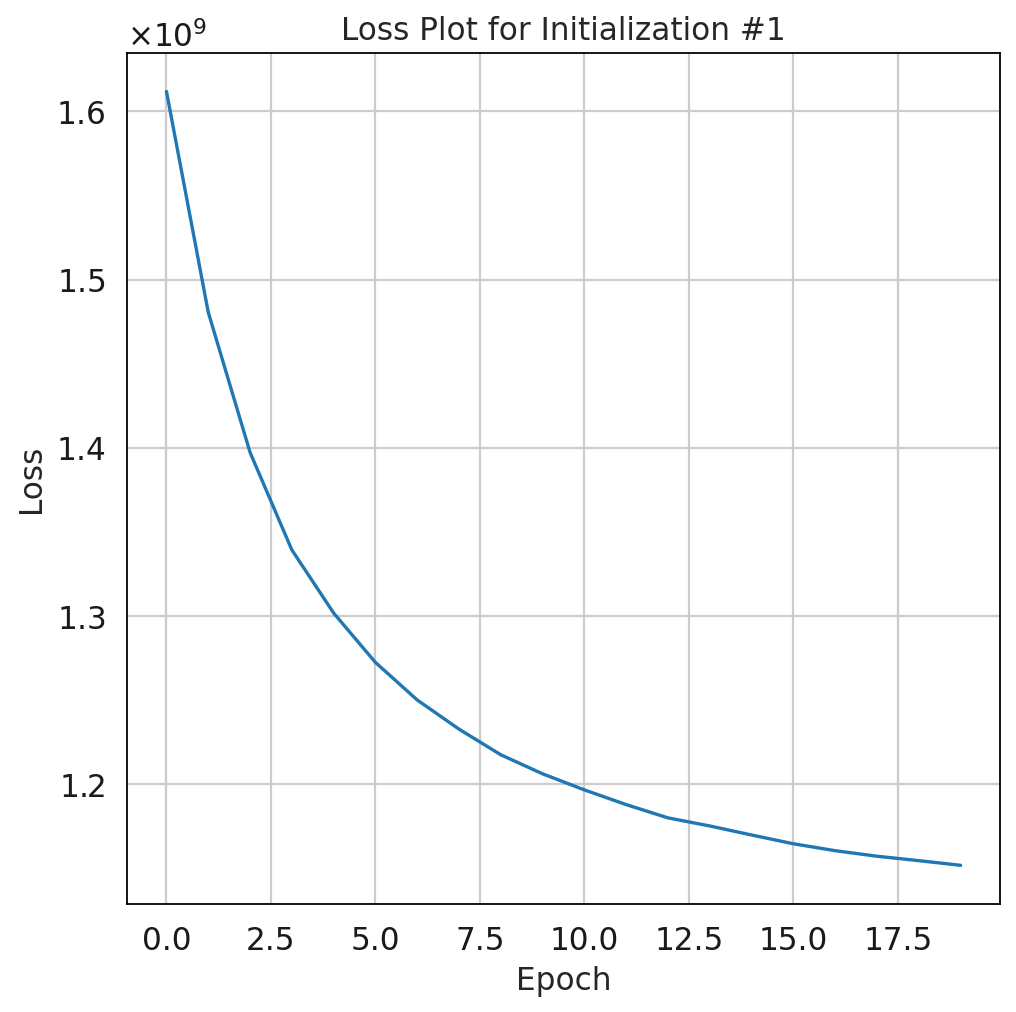

In [6]:
# Let's initialize the LeafletFA class 
leaflet_model = LeafletFA.LeafletFA(adata=adata, K=K, junc_specific_prior = junc_specific_prior, waypoints_use=waypoints_use, 
                           input_conc_prior = input_conc, num_epochs=num_epochs, print_epochs=print_epochs, 
                           ELBO_num_particles=5, 
                           lr=lr, gamma=0.05, num_samples=100)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

# Train the model 
leaflet_model.train(num_initializations=num_inits)

# Get the best initialization and extract all the latent variables at this initialization
# If you want the latent variables from a different initialization, you can pass the index of that initialization to the get_all_variables() function
leaflet_model.get_all_variables()

In [7]:
# let's look at the results 
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in leaflet_model.latent_results]

# Calculate correlations between initializations if more than 2 
if num_inits > 1:
    avg_corr, median_corr, min_corr = utils.calculate_and_plot_correlations(assign_matrices)
else: 
    avg_corr, median_corr, min_corr = None, None, None  # Set default values when there's only one initialization

In [8]:
# Prune K: note this updates all the latent variables in the model to only include estimates for the pruned K
leaflet_model.prune_K()

The K before pruning is 30
The K after pruning is 30
Upating K to 30 in the LeafletFA object.


In [9]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"
adata.obsm[LEAFLETFA_LATENT_KEY] = leaflet_model.assign_post # assign_post is the posterior assignment cell-factor activity matrix 

sc.pp.neighbors(adata, use_rep=LEAFLETFA_LATENT_KEY)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cell_type_grouped", "age"], wspace=0.75)

KeyError: 'Could not find key cell_type_grouped in .var_names or .obs.columns.'

<Figure size 1960x560 with 0 Axes>

In [ ]:
cell_tye_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata.obs.cell_type_grouped.values)
age_silhouette = ds.calculate_silhouette_score(leaflet_model.assign_post, adata.obs.age.values)

print(f"Silhouette score for cell types: {cell_tye_silhouette}")
print(f"Silhouette score for age: {age_silhouette}")

In [ ]:
pi_df = pd.DataFrame(leaflet_model.pi, columns=["factor_assignment_probabilities"])
pi_df["factor_K"] = pi_df.index+1

# Sort by factor_assignment_probabilities in descending order
pi_df = pi_df.sort_values(by="factor_assignment_probabilities", ascending=False)

# Make sorted barplot
plt.figure(figsize=(10, 5))
sns.barplot(x="factor_K", y="factor_assignment_probabilities", data=pi_df, order=pi_df["factor_K"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Assignment Probabilities")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors
plt.show()

In [ ]:
# Number of samples to capture variability
num_samples = 500  

# Sample multiple shape parameters for prior and original distributions which was ~ Gamma(2,2)
a_prior_samples = np.random.gamma(leaflet_model.a_shape, leaflet_model.a_rate, size=num_samples)
b_prior_samples = np.random.gamma(leaflet_model.a_shape, leaflet_model.a_rate, size=num_samples)

a_orig_samples = np.random.gamma(2, 2, size=num_samples)
b_orig_samples = np.random.gamma(2, 2, size=num_samples)

# Compute mean and confidence intervals for the Beta distributions
x = np.linspace(0, 1, num_samples)

# Compute PDFs for each sampled (a,b) pair
prior_pdfs = np.array([stats.beta.pdf(x, a, b) for a, b in zip(a_prior_samples, b_prior_samples)])
orig_pdfs = np.array([stats.beta.pdf(x, a, b) for a, b in zip(a_orig_samples, b_orig_samples)])

# Compute the mean and 95% confidence intervals for each x
prior_mean = np.mean(prior_pdfs, axis=0)
prior_lower = np.percentile(prior_pdfs, 2.5, axis=0)
prior_upper = np.percentile(prior_pdfs, 97.5, axis=0)

orig_mean = np.mean(orig_pdfs, axis=0)
orig_lower = np.percentile(orig_pdfs, 2.5, axis=0)
orig_upper = np.percentile(orig_pdfs, 97.5, axis=0)

print(f"The mean of the prior Beta distribution is {np.mean(a_prior_samples/(a_prior_samples+b_prior_samples))}")
print(f"The mean of the original Beta distribution is {np.mean(a_orig_samples/(a_orig_samples+b_orig_samples))}")

# Plot mean prior Beta distribution with confidence interval shading
plt.plot(x, prior_mean, label="Prior (Mean)", color='blue', linestyle='dashed')
plt.fill_between(x, prior_lower, prior_upper, color='blue', alpha=0.2, label="Prior (95% CI)")

# Plot mean original Beta distribution with confidence interval shading
plt.plot(x, orig_mean, label="Original (Mean)", color='green', linestyle='dashed')
plt.fill_between(x, orig_lower, orig_upper, color='green', alpha=0.2, label="Original (95% CI)")

# Labels and legend
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.title("Comparing learned beta shape and rape prior, and Original Beta Distributions")
plt.show()

In [ ]:
if junc_specific_prior:

    num_samples=100
    x = np.linspace(0, 1, num_samples)
    K = leaflet_model.K

    # Plot K Beta distributions, each corresponding to a junction's a and b
    plt.figure(figsize=(10, 6))
    for i in range(K):
        a_j = leaflet_model.a[i]
        b_j = leaflet_model.b[i]
        print(f"The mean of the {i}th factor's Beta distribution is: {a_j / (a_j + b_j)}")

        beta_pdf = stats.beta.pdf(x, a_j, b_j)
        plt.plot(x, beta_pdf, alpha=0.5)  

    # Labels and legend
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"Visualization of {K} Junction-Specific Beta Distributions")
    plt.legend(loc="upper right", fontsize=8, ncol=2)  # Keep legend readable
    plt.show()

else:

    # sample from the learned prior on beta with leafletmodel.a and leafletmodel.b
    num_samples = 1000
    x = np.linspace(0, 1, num_samples)
    a = leaflet_model.a
    b = leaflet_model.b
    
    # sample from this beta distribution only one global a and b value... 
    beta_pdf = stats.beta.pdf(x, a, b)
    plt.plot(x, beta_pdf, label="Learned Beta Distribution")

In [ ]:
SJ_DSS = ds.compute_z_score_dss(leaflet_model.psis_loc, leaflet_model.psis_scale, leaflet_model.pi, adata.var_names)
SJ_DSS.shape # K by J matrix let's add it to anndata 
LEAFLETFA_SJ_DSS_KEY = "SJ_DSS"
adata.varm[LEAFLETFA_SJ_DSS_KEY] = SJ_DSS

# Add perplexity values to AnnData var object 
perplexity_df = ds.compute_junction_perplexity(adata, leafletfa_sj_dss_key="SJ_DSS")
adata.var["perplexity"] = perplexity_df["Perplexity"].values

# Extract top N factor markers for each factor
factor_markers_df = ds.get_factor_markers(adata, leafletfa_sj_dss_key="SJ_DSS", pval_thresh=0.05, top_n=100)

In [ ]:
# Use leaflet_model.psi_samples to compute the mean and standard deviation of the posterior distribution of psi for every factor-junction pair
sampled_means = leaflet_model.psi_samples.mean(dim=0)
sampled_stddevs = leaflet_model.psi_samples.std(dim=0)

In [ ]:
SJ_DSS = ds.compute_z_score_dss(sampled_means, sampled_stddevs, leaflet_model.pi, adata.var_names)


In [ ]:
LEAFLETFA_SJ_DSS_KEY = "SJ_DSS_SAMPLES"
adata.varm[LEAFLETFA_SJ_DSS_KEY] = SJ_DSS

# Add perplexity values to AnnData var object
perplexity_df = ds.compute_junction_perplexity(adata, leafletfa_sj_dss_key="SJ_DSS_SAMPLES")
adata.var["perplexity_samples"] = perplexity_df["Perplexity"].values

# Extract top N factor markers for each factor
factor_markers_df = ds.get_factor_markers(adata, leafletfa_sj_dss_key="SJ_DSS_SAMPLES", pval_thresh=0.05, top_n=100)
factor_markers_df

In [ ]:
# For a given junction, let's extract it's sampled PSI values and plot them for each factor 
junction_id = 72705
# Get the sampled PSI values for the junction
sampled_psis = leaflet_model.psi_samples[:, :, junction_id] # shape is (num_samples, K)
# Plot the sampled PSI values for each factor like a violin plot
plt.figure(figsize=(15, 6))
# Show mean in the violin plot
sns.violinplot(data=sampled_psis, inner="quart", scale="width", linewidth=1.5)
plt.xlabel("Factor K")
plt.ylabel("Sampled PSI")

In [ ]:
sampled_psis.shape

In [ ]:
# let's plot a few PSI values for a given junction-factor pair to ensure it is more or less normally distributed
for k in range(K):
    plt.figure(figsize=(8, 6))
    sns.kdeplot(sampled_psis[:, k], label=f"Factor {k}")
    plt.xlabel("PSI")
    plt.ylabel("Density")
    plt.title(f"Factor {k} Sampled PSI for Junction {junction_id}")

In [ ]:
# look at distribution of z-scores in factor_0 and factor_1
plt.figure(figsize=(10, 5))
sns.histplot(SJ_DSS["factor_0"], bins=100, color="blue", alpha=0.5, label="Factor 0")
sns.histplot(SJ_DSS["factor_1"], bins=100, color="red", alpha=0.5, label="Factor 1")
plt.xlabel("Z-Score")
plt.ylabel("Frequency")